In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import spacy
import gensim
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part2 feature-creation/code_features_extracts.csv')
leetcode_questions_df['num_of_contest'] = leetcode_questions_df.num_of_contest.astype('category')
leetcode_questions_df['question_number'] = leetcode_questions_df.question_number.astype('category')
leetcode_questions_df['finish_time'] = pd.to_datetime(leetcode_questions_df['finish_time'], format='%H:%M:%S').astype(int)
leetcode_questions_df['question_finish_time'] = pd.to_datetime(leetcode_questions_df['question_finish_time'], format='%H:%M:%S').astype(int)

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     61834 non-null  object  
 1   country                      61834 non-null  object  
 2   contest_url                  61834 non-null  object  
 3   num_of_contest               61834 non-null  category
 4   finish_time                  61834 non-null  int64   
 5   is_weekly                    61834 non-null  bool    
 6   rank                         61834 non-null  int64   
 7   score                        61834 non-null  int64   
 8   user_global_rank             61834 non-null  float64 
 9   question_number              61834 non-null  category
 10  question_language            61834 non-null  object  
 11  question_code                61834 non-null  object  
 12  question_finish_time         61834 non-null  int64   
 13  n

In [ ]:
leetcode_questions_df.head()

,username,country,contest_url,num_of_contest,finish_time,is_weekly,rank,score,user_global_rank,question_number,...,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,fmota,Brazil,https://leetcode.com/contest/weekly-contest-36...,367,-2208988044000000000,True,2,17,486427.0,1,...,12,1,2,1,0.000000,0.0,0.045455,0.090909,0.045455,0.0
1,nicholask_17,Hong Kong,https://leetcode.com/contest/weekly-contest-36...,367,-2208988018000000000,True,3,17,27684.0,1,...,18,1,2,6,0.000000,0.0,0.032258,0.064516,0.193548,0.0
2,skywalkert,China,https://leetcode.com/contest/weekly-contest-36...,367,-2208987996000000000,True,4,17,16.0,1,...,17,1,1,2,0.000000,0.0,0.037037,0.037037,0.074074,0.0
3,hank55663,Taiwan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987929000000000,True,7,17,6234.0,1,...,12,1,1,5,0.037037,0.0,0.040000,0.040000,0.200000,0.2
4,DimmyT,Kazakhstan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987916000000000,True,8,17,702585.0,1,...,10,1,2,1,0.000000,0.0,0.052632,0.105263,0.052632,0.0


In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'python']

In [ ]:
leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15241 entries, 12 to 61824
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     15241 non-null  object  
 1   country                      15241 non-null  object  
 2   contest_url                  15241 non-null  object  
 3   num_of_contest               15241 non-null  category
 4   finish_time                  15241 non-null  int64   
 5   is_weekly                    15241 non-null  bool    
 6   rank                         15241 non-null  int64   
 7   score                        15241 non-null  int64   
 8   user_global_rank             15241 non-null  float64 
 9   question_number              15241 non-null  category
 10  question_language            15241 non-null  object  
 11  question_code                15241 non-null  object  
 12  question_finish_time         15241 non-null  int64   
 13  numbe

In [ ]:
leetcode_questions_df.country.value_counts()

country
United States    5557
India            3092
Taiwan           1518
Canada           1071
China             628
                 ... 
Sudan               2
Pakistan            2
Philippines         1
Ireland             1
Belize              1
Name: count, Length: 78, dtype: int64

<Axes: ylabel='Frequency'>

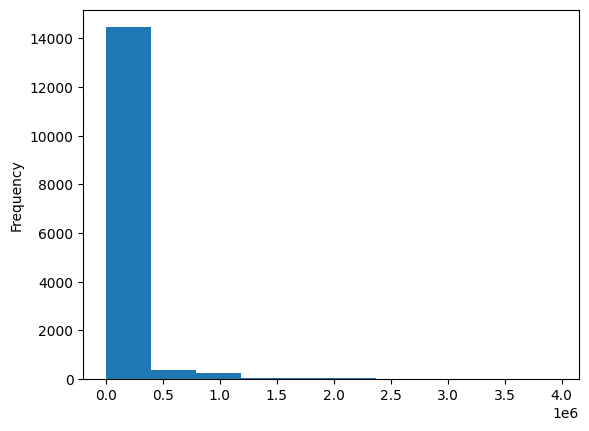

In [ ]:
leetcode_questions_df['user_global_rank'].plot.hist()

In [ ]:
leetcode_questions_df['user_global_rank'].max(), leetcode_questions_df['user_global_rank'].mean(), leetcode_questions_df['user_global_rank'].median()

(3956946.0, 86589.73545042975, 8766.0)

<Axes: ylabel='Frequency'>

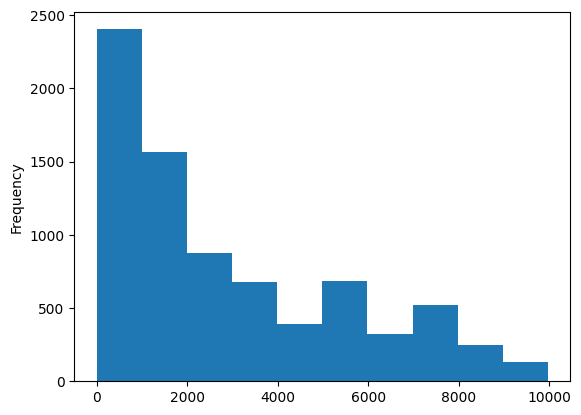

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['user_global_rank'] < 10000]

leetcode_questions_df['user_global_rank'].plot.hist()

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df.groupby('country')['country'].transform('size') > 100]
leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')

<ipython-input-11-22d56a376d39>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')


array([<Axes: title={'center': 'Australia'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Canada'}, ylabel='Frequency'>,
       <Axes: title={'center': 'China'}, ylabel='Frequency'>,
       <Axes: title={'center': 'India'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Japan'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Russia'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Singapore'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Taiwan'}, ylabel='Frequency'>,
       <Axes: title={'center': 'United Kingdom'}, ylabel='Frequency'>,
       <Axes: title={'center': 'United States'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Vietnam'}, ylabel='Frequency'>],
      dtype=object)

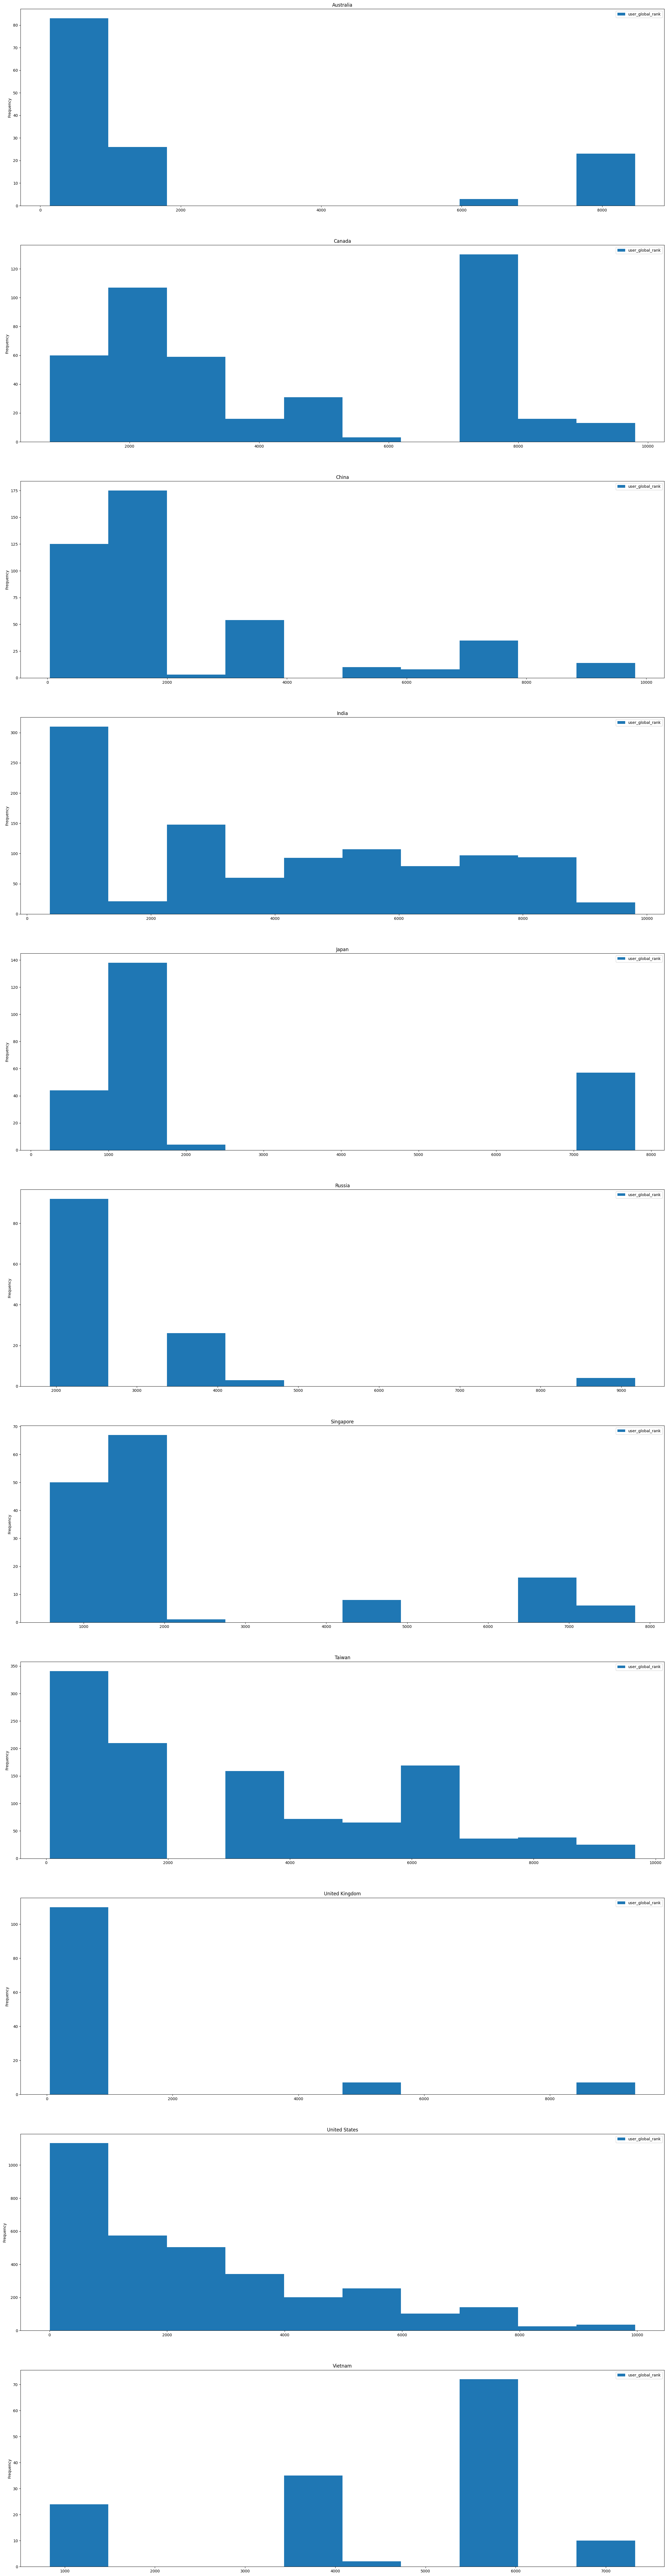

In [ ]:
leetcode_questions_df.plot.hist(column=["user_global_rank"], by="country", figsize=(30, 120))

In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df['country']

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7234 entries, 12 to 61706
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     7234 non-null   object  
 1   contest_url                  7234 non-null   object  
 2   num_of_contest               7234 non-null   category
 3   finish_time                  7234 non-null   int64   
 4   is_weekly                    7234 non-null   bool    
 5   rank                         7234 non-null   int64   
 6   score                        7234 non-null   int64   
 7   user_global_rank             7234 non-null   float64 
 8   question_number              7234 non-null   category
 9   question_language            7234 non-null   object  
 10  question_code                7234 non-null   object  
 11  question_finish_time         7234 non-null   int64   
 12  number_of_lines              7234 non-null   int64   
 13  names_

# Non text features

In [ ]:
X_nontext=X[['user_global_rank', 'num_of_contest',
            'finish_time', 'is_weekly', 'score', 'username',
            'question_number', 'question_finish_time', 'number_of_lines',
            'token_count', 'variables_count', 'function_count', 'loop_count',
            'condition_count', 'single_line_comment_density',
            'multiline_comment_density', 'function_density', 'loop_density',
            'condition_density', 'comment_tokens_density']]
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7234 entries, 12 to 61706
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   user_global_rank             7234 non-null   float64 
 1   num_of_contest               7234 non-null   category
 2   finish_time                  7234 non-null   int64   
 3   is_weekly                    7234 non-null   bool    
 4   score                        7234 non-null   int64   
 5   username                     7234 non-null   object  
 6   question_number              7234 non-null   category
 7   question_finish_time         7234 non-null   int64   
 8   number_of_lines              7234 non-null   int64   
 9   token_count                  7234 non-null   int64   
 10  variables_count              7234 non-null   int64   
 11  function_count               7234 non-null   int64   
 12  loop_count                   7234 non-null   int64   
 13  condit

In [ ]:
X_train_nontext = X_nontext.iloc[:0]
X_test_nontext = X_nontext.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = Y.unique()

for country in unique_countries:
    country_data = X_nontext[Y == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_nontext = X_train_nontext._append(country_data.iloc[train_indices], ignore_index = True)
        X_test_nontext = X_test_nontext._append(country_data.iloc[test_indices], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_nontext.drop('username', axis=1, inplace=True)
X_test_nontext.drop('username', axis=1, inplace=True)

In [ ]:
#handle categorical columns

categorical = X_train_nontext.dtypes == 'category'

preprocess = make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

baseline_model = Pipeline([('encoder_scaler',preprocess),
                           ('svc',SVC())])

In [ ]:
param_grid = [{'svc__C': np.logspace(0,3,16)}]
svc_cv= GridSearchCV(baseline_model, param_grid,cv=5,return_train_score=True)
svc_cv.fit(X_train_nontext, y_train)
print("nontext grid SVC train score ", svc_cv.score(X_train_nontext, y_train))
print("nontext grid SVC test score ", svc_cv.score(X_test_nontext, y_test))
print("nontext SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_nontext), average='weighted'))
print("nontext SVC test f1 score ", f1_score(y_test,svc_cv.predict(X_test_nontext), average='weighted'))
svc_cv.best_params_

nontext grid SVC train score  0.5118942731277533
nontext grid SVC test score  0.4990378447722899
nontext SVC train f1 score  0.4095453598159972
nontext SVC test f1 score  0.38901607053969894


{'svc__C': 1.5848931924611134}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

     Australia       0.00      0.00      0.00        85
        Canada       0.00      0.00      0.00        91
         China       0.00      0.00      0.00        58
         India       0.29      0.17      0.22       220
         Japan       0.00      0.00      0.00        11
        Russia       0.00      0.00      0.00         3
     Singapore       0.00      0.00      0.00        57
        Taiwan       0.08      0.04      0.05       142
United Kingdom       0.00      0.00      0.00         7
 United States       0.54      0.91      0.68       810
       Vietnam       0.00      0.00      0.00        75

      accuracy                           0.50      1559
     macro avg       0.08      0.10      0.09      1559
  weighted avg       0.33      0.50      0.39      1559

f1_score :  0.38901607053969894


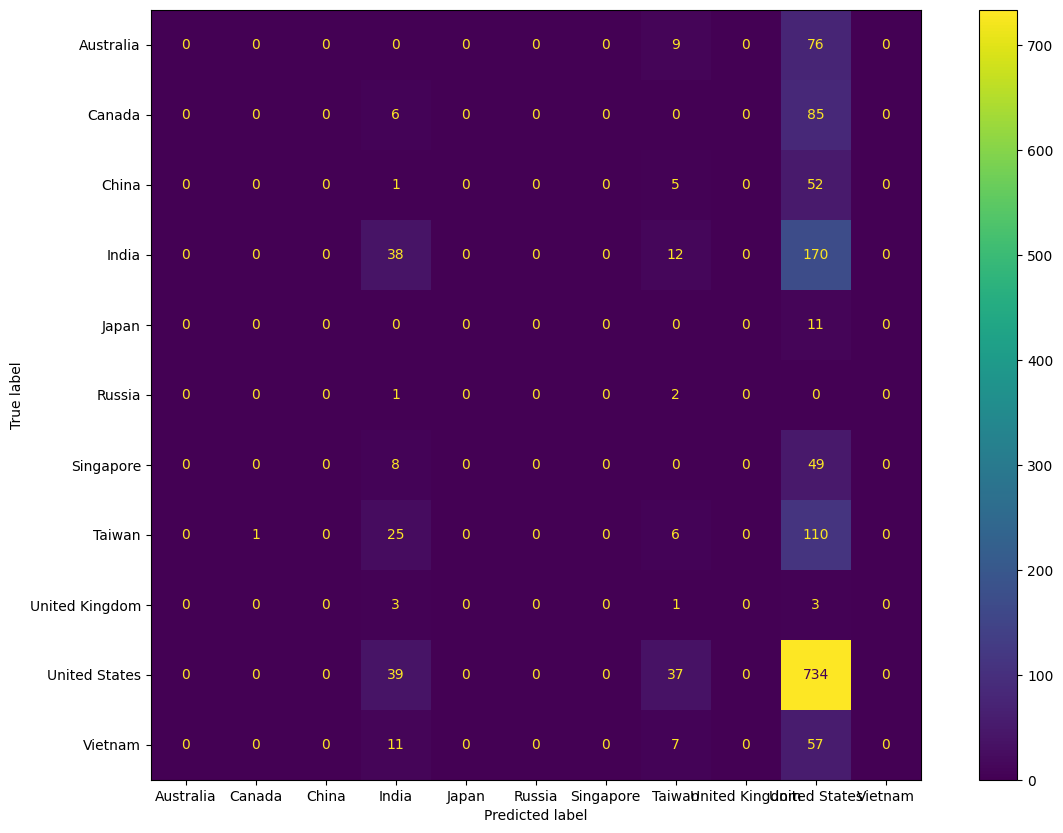

In [ ]:
y_pred_test = svc_cv.predict(X_test_nontext)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# simple BOW

In [ ]:
X_text=X[['username','question_code']]
X_train_text = X_text.iloc[:0]
X_test_text = X_text.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = Y.unique()

for country in unique_countries:
    country_data = X_text[Y == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_text = X_train_text._append(country_data.iloc[train_indices], ignore_index = True)
        X_test_text = X_test_text._append(country_data.iloc[test_indices], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_text = X_train_text.question_code
X_test_text = X_test_text.question_code

In [ ]:
custom_token_pattern = r'\b[A-Za-z_]\w*\b'

vect = CountVectorizer(stop_words='english', min_df=10, token_pattern=custom_token_pattern, max_df=0.8)
X_train_simple=vect.fit_transform(X_train_text)
X_test_simple=vect.transform(X_test_text)
print(vect.get_feature_names_out())

['_' '__getitem__' '__init__' 'a1' 'a2' 'aa' 'aaacaaaa'
 'abcdefghijklmnopqrstuvwxyz' 'abs' 'acc' 'access_times' 'accu'
 'accumulate' 'add' 'adj' 'aeiou' 'algorithm' 'ans' 'ans1' 'ans2' 'answer'
 'append' 'apple' 'area' 'areaofmaxdiagonal' 'aresimilar' 'argparse' 'arr'
 'arr1' 'arr2' 'array' 'ascii_lowercase' 'assert' 'asyncio' 'avg' 'b' 'b1'
 'b2' 'base' 'basis' 'batterypercentages' 'bb' 'beautifulindices'
 'beautifulsubstrings' 'best' 'bfs' 'big' 'bin' 'bisect' 'bisect_left'
 'bisect_right' 'bit' 'bit_count' 'bit_length' 'bits' 'bool' 'bottomleft'
 'break' 'build' 'c' 'c1' 'c2' 'ca' 'cache' 'cache_clear' 'calc'
 'calculate' 'calculates' 'calendar' 'cand' 'candidate' 'candidates'
 'cansortarray' 'capacity' 'case' 'cc' 'ceil' 'ch' 'change' 'changed'
 'changeindices' 'char' 'characters' 'chars' 'check' 'child' 'children'
 'chr' 'ci' 'cnt' 'cnt1' 'cnt2' 'cnts' 'coin' 'coins' 'col' 'collections'
 'cols' 'comb' 'combinations' 'common' 'compute' 'computelpsarray'
 'configparser' 'consider' 

In [ ]:
svc = SVC().fit(X_train_simple, y_train)
print("simple BOW SVC train score ",svc.score(X_train_simple, y_train))
print("simple BOW SVC test score ",svc.score(X_test_simple, y_test))
print("simple BOW SVC train f1 score ", f1_score(y_train, svc.predict(X_train_simple), average='weighted'))
print("simple BOW SVC test f1 score ", f1_score(y_test, svc.predict(X_test_simple), average='weighted'))

simple BOW SVC train score  0.5628193832599119
simple BOW SVC test score  0.5054522129570237
simple BOW SVC train f1 score  0.49117255440688373
simple BOW SVC test f1 score  0.3577848913134651


# n-grams tf-idf

In [ ]:
wordnet_lem = WordNetLemmatizer()

X_train_lemma=X_train_text.apply(wordnet_lem.lemmatize)
X_test_lemma=X_test_text.apply(wordnet_lem.lemmatize)

In [ ]:
tfidf_pipeline = make_pipeline(CountVectorizer(stop_words='english',ngram_range=(2,10),min_df=10, max_df = 0.8),
                      Normalizer(),
                      TfidfTransformer(),
                      SVC(random_state=0),memory="cache_folder")

In [ ]:
param_grid = [{
    'countvectorizer__ngram_range':[(2, 5), (5,9), (2,10)],
    'svc__C':np.logspace(-2,2,5)}]

svc_cv= GridSearchCV(tfidf_pipeline, param_grid,cv=5,return_train_score=True)

svc_cv.fit(X_train_lemma, y_train)

print("n-grams grid SVC train score ",svc_cv.score(X_train_lemma, y_train))
print("n-grams grid SVC test score ",svc_cv.score(X_test_lemma, y_test))
print("n-grams SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_lemma), average='weighted'))
print("n-grams SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_lemma), average='weighted'))
svc_cv.best_params_

n-grams grid SVC train score  0.44599118942731275
n-grams grid SVC test score  0.5195638229634381
n-grams SVC train f1 score  0.2802697152633298
n-grams SVC test f1 score  0.3552948050657534


{'countvectorizer__ngram_range': (2, 5), 'svc__C': 0.09999999999999999}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

     Australia       0.00      0.00      0.00        85
        Canada       0.00      0.00      0.00        91
         China       0.00      0.00      0.00        58
         India       0.00      0.00      0.00       220
         Japan       0.00      0.00      0.00        11
        Russia       0.00      0.00      0.00         3
     Singapore       0.00      0.00      0.00        57
        Taiwan       0.00      0.00      0.00       142
United Kingdom       0.00      0.00      0.00         7
 United States       0.52      1.00      0.68       810
       Vietnam       0.00      0.00      0.00        75

      accuracy                           0.52      1559
     macro avg       0.05      0.09      0.06      1559
  weighted avg       0.27      0.52      0.36      1559

f1_score :  0.3552948050657534


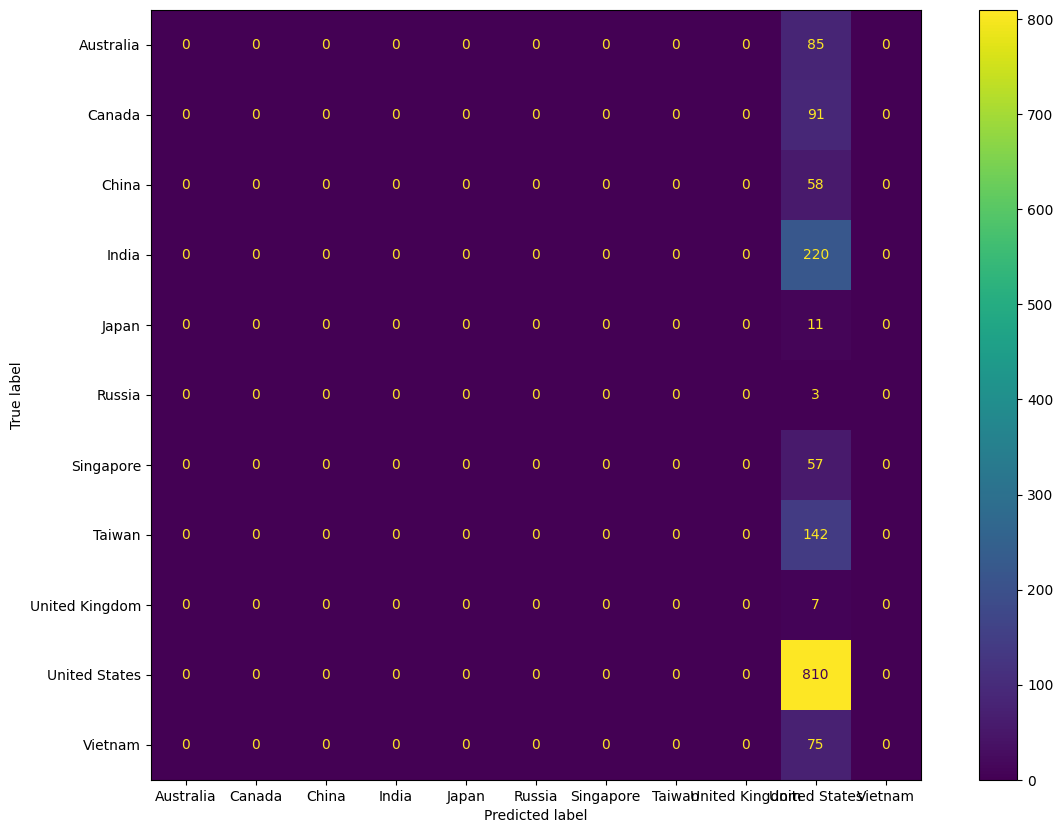

In [ ]:
y_pred_test = svc_cv.predict(X_test_lemma)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
results = pd.DataFrame(svc_cv.cv_results_)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_countvectorizer__ngram_range,param_svc__C,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,13.944558,0.880870,1.770506,0.241435,"(2, 5)",0.01,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.441410,0.441410,0.441410,...,0.441233,0.000352,5,0.441189,0.441189,0.441189,0.441189,0.441410,0.441233,0.000088
1,14.636575,0.949374,1.846833,0.269807,"(2, 5)",0.1,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.444934,0.444934,0.446696,...,0.445991,0.001027,1,0.446256,0.446256,0.445815,0.446035,0.445595,0.445991,0.000257
2,15.513923,0.851930,1.794805,0.315730,"(2, 5)",1.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.451101,0.414978,0.422907,...,0.434537,0.013482,10,0.624009,0.610132,0.613436,0.600441,0.580396,0.605683,0.014715
3,16.274309,0.753174,1.769027,0.307900,"(2, 5)",10.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.420264,0.407048,0.443172,...,0.441762,0.027427,4,0.973789,0.961674,0.951322,0.945374,0.940969,0.954626,0.011831
4,17.622900,3.312895,1.804227,0.243382,"(2, 5)",100.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.412335,0.407048,0.431718,...,0.438414,0.029033,9,0.981938,0.968722,0.962775,0.959251,0.955947,0.965727,0.009144
5,7.584630,0.686948,0.720808,0.112062,"(5, 9)",0.01,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.441410,0.441410,0.441410,...,0.441233,0.000352,5,0.441189,0.441189,0.441189,0.441189,0.441410,0.441233,0.000088
6,5.725619,0.591959,0.819814,0.172960,"(5, 9)",0.1,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.444934,0.444934,0.446696,...,0.445991,0.001027,1,0.446256,0.446256,0.445815,0.446035,0.445595,0.445991,0.000257
7,5.808848,0.711181,0.733446,0.149495,"(5, 9)",1.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.414978,0.360352,0.395595,...,0.391894,0.018751,13,0.474890,0.480837,0.479956,0.482379,0.482159,0.480044,0.002725
8,5.792495,0.868515,0.738082,0.155065,"(5, 9)",10.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.365639,0.342731,0.354185,...,0.354714,0.010463,14,0.566960,0.577533,0.577974,0.576652,0.564758,0.572775,0.005706
9,6.021717,0.754527,0.760668,0.095329,"(5, 9)",100.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.360352,0.341850,0.340969,...,0.349780,0.012221,15,0.598238,0.611013,0.609692,0.602423,0.588987,0.602070,0.008050


#Pretrained Work Vectors

In [ ]:
%%python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 2.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("en_core_web_lg", disable=["tagger", "parser", "ner","lemmatizer"])
docs_train = [nlp(d).vector for d in X_train_text]
docs_test = [nlp(d).vector for d in X_test_text]

In [ ]:
X_train_w2v = np.vstack(docs_train)
X_test_w2v = np.vstack(docs_test)
X_train_w2v.shape, X_test_w2v.shape

((5675, 300), (1559, 300))

In [ ]:
param_grid = [{'C':np.logspace(-2,2,20)}]
svc_cv= GridSearchCV(SVC(random_state=0), param_grid,cv=5)
svc_cv.fit(X_train_w2v, y_train)
print("spacy grid SVC train score ",svc_cv.score(X_train_w2v, y_train))
print("spacy grid SVC test score ",svc_cv.score(X_test_w2v, y_test))
print("spacy SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_w2v), average='weighted'))
print("spacy SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_w2v), average='weighted'))
svc_cv.best_params_

spacy grid SVC train score  0.6206167400881057
spacy grid SVC test score  0.4663245670301475
spacy SVC train f1 score  0.5739627973278377
spacy SVC test f1 score  0.37348896020671063


{'C': 61.58482110660261}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

     Australia       0.00      0.00      0.00        85
        Canada       0.00      0.00      0.00        91
         China       0.09      0.02      0.03        58
         India       0.30      0.16      0.21       220
         Japan       0.00      0.00      0.00        11
        Russia       0.00      0.00      0.00         3
     Singapore       0.00      0.00      0.00        57
        Taiwan       0.08      0.06      0.07       142
United Kingdom       0.17      0.14      0.15         7
 United States       0.53      0.84      0.65       810
       Vietnam       0.00      0.00      0.00        75

      accuracy                           0.47      1559
     macro avg       0.11      0.11      0.10      1559
  weighted avg       0.33      0.47      0.37      1559

f1_score :  0.37348896020671063


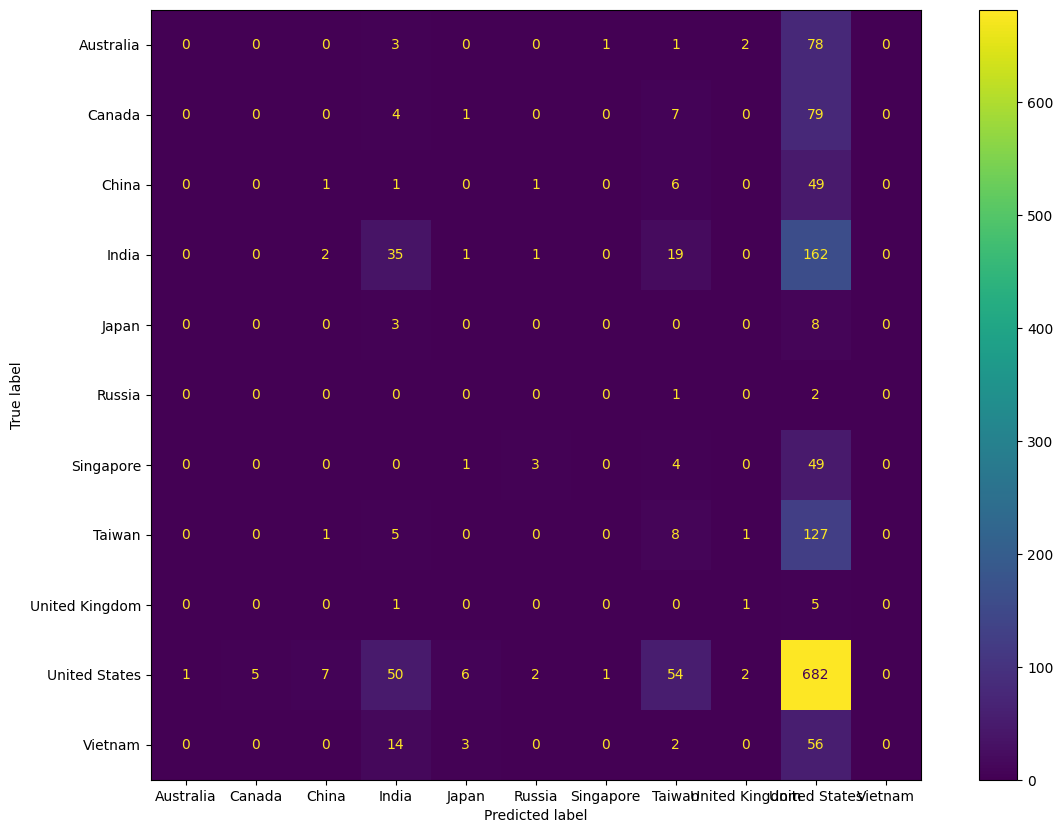

In [ ]:
y_pred_test = svc_cv.predict(X_test_w2v)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
def read_corpus(text, tokens_only=False):
    for i, line in enumerate(text):
        tokens = gensim.utils.simple_preprocess(line)
        if tokens_only:
            yield tokens
        else:
        # For training data, add tags
            yield gensim.models.doc2vec.TaggedDocument(tokens, [i])

train_corpus = list(read_corpus(X_train_text))
test_corpus = list(read_corpus(X_test_text, tokens_only=True))

In [ ]:
model = gensim.models.doc2vec.Doc2Vec(vector_size=50, min_count=2)
model.build_vocab(train_corpus)
model.train(train_corpus, total_examples=model.corpus_count, epochs=55)

In [ ]:
vectors = [model.infer_vector(train_corpus[doc_id].words) for doc_id in range(len(train_corpus))]
X_train_doc2vec = np.vstack(vectors)

test_vectors = [model.infer_vector(test_corpus[doc_id]) for doc_id in range(len(test_corpus))]
X_test_doc2vec = np.vstack(test_vectors)

X_train_doc2vec.shape , X_test_doc2vec.shape

((5675, 50), (1559, 50))

In [ ]:
param_grid = [{'C':np.logspace(-2,2,20)}]
svc_cv= GridSearchCV(SVC(random_state=0), param_grid,cv=5)
svc_cv.fit(X_train_doc2vec, y_train)
print("gensim grid SVC train score ",svc_cv.score(X_train_doc2vec, y_train))
print("gensim grid SVC test score ",svc_cv.score(X_test_doc2vec, y_test))
print("gensim SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_doc2vec), average='weighted'))
print("gensim SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_doc2vec), average='weighted'))
svc_cv.best_params_

gensim grid SVC train score  0.7326872246696036
gensim grid SVC test score  0.46889031430404104
gensim SVC train f1 score  0.7186825452113658
gensim SVC test f1 score  0.364249545375667


{'C': 3.359818286283781}

# Combine Text and non text features

In [ ]:
X_train_combined=pd.concat([X_train_lemma,X_train_nontext],axis=1)

X_test_combined=pd.concat([X_test_lemma,X_test_nontext],axis=1)

X_train_combined.head(5)

,question_code,user_global_rank,num_of_contest,finish_time,is_weekly,score,question_number,question_finish_time,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,"class Solution:\n def findIndices(self, num...",3613.0,367,-2208987653000000000,True,17,1,-2208988722000000000,10,22,7,1,2,1,0.0,0.0,0.045455,0.090909,0.045455,0.0
1,class Solution(object):\n def findIndices(s...,30.0,367,-2208987403000000000,True,17,1,-2208988660000000000,14,25,6,1,2,1,0.0,0.0,0.040000,0.080000,0.040000,0.0
2,"class Solution:\n def findIndices(self, num...",2664.0,367,-2208987317000000000,True,17,1,-2208988696000000000,7,21,6,1,2,1,0.0,0.0,0.047619,0.095238,0.047619,0.0
3,"class Solution:\n def findIndices(self, num...",1250.0,367,-2208986475000000000,True,17,1,-2208988697000000000,9,23,8,1,2,1,0.0,0.0,0.043478,0.086957,0.043478,0.0
4,"class Solution:\n def findIndices(self, num...",2401.0,367,-2208986317000000000,True,17,1,-2208988686000000000,12,23,8,1,2,1,0.0,0.0,0.043478,0.086957,0.043478,0.0


In [ ]:
X_train_combined.dtypes

question_code                    object
user_global_rank                float64
num_of_contest                 category
finish_time                       int64
is_weekly                          bool
score                             int64
question_number                category
question_finish_time              int64
number_of_lines                   int64
token_count                       int64
variables_count                   int64
function_count                    int64
loop_count                        int64
condition_count                   int64
single_line_comment_density     float64
multiline_comment_density       float64
function_density                float64
loop_density                    float64
condition_density               float64
comment_tokens_density          float64
dtype: object

In [ ]:
categorical = X_train_combined.dtypes == 'category'

tfidf = make_pipeline(CountVectorizer(stop_words='english', ngram_range=(2,10), min_df=10, token_pattern=custom_token_pattern, max_df=0.8),
                      Normalizer(),
                      TfidfTransformer(),memory="cache_folder")

make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

preprocessor_combined = make_column_transformer((tfidf, 'question_code'),
                                                (StandardScaler(), ~categorical & (X_train_combined.dtypes != object)),
                                                (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

combine_model = Pipeline([('transformer',preprocessor_combined),
                           ('svc',SVC(random_state=0))])

In [ ]:
scores = cross_val_score(combine_model, X_train_combined, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.4592070484581498


In [ ]:
param_grid = [{
    'transformer__pipeline__countvectorizer__ngram_range':[(2, 5), (3, 6)],
    'svc__C':np.logspace(-2,2,5)}]

svc_cv= GridSearchCV(combine_model, param_grid,cv=5,return_train_score=True)

svc_cv.fit(X_train_combined, y_train)

print("combined grid SVC train score ",svc_cv.score(X_train_combined, y_train))
print("combined grid SVC test score ",svc_cv.score(X_test_combined, y_test))
print("combined SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_combined), average='weighted'))
print("combined SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_combined), average='weighted'))
svc_cv.best_params_

combined grid SVC train score  0.49832599118942733
combined grid SVC test score  0.514432328415651
combined SVC train f1 score  0.3837626640179581
combined SVC test f1 score  0.3941242337508798


{'svc__C': 1.0, 'transformer__pipeline__countvectorizer__ngram_range': (2, 5)}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

     Australia       0.00      0.00      0.00        50
        Canada       1.00      0.01      0.03       344
         China       0.00      0.00      0.00       366
         India       0.59      0.26      0.37       808
         Japan       1.00      0.04      0.08       232
        Russia       0.00      0.00      0.00       122
     Singapore       0.00      0.00      0.00        91
        Taiwan       0.66      0.13      0.22       973
United Kingdom       1.00      0.06      0.11       117
 United States       0.48      0.98      0.65      2504
       Vietnam       0.00      0.00      0.00        68

      accuracy                           0.50      5675
     macro avg       0.43      0.14      0.13      5675
  weighted avg       0.53      0.50      0.38      5675

f1_score :  0.3837626640179581


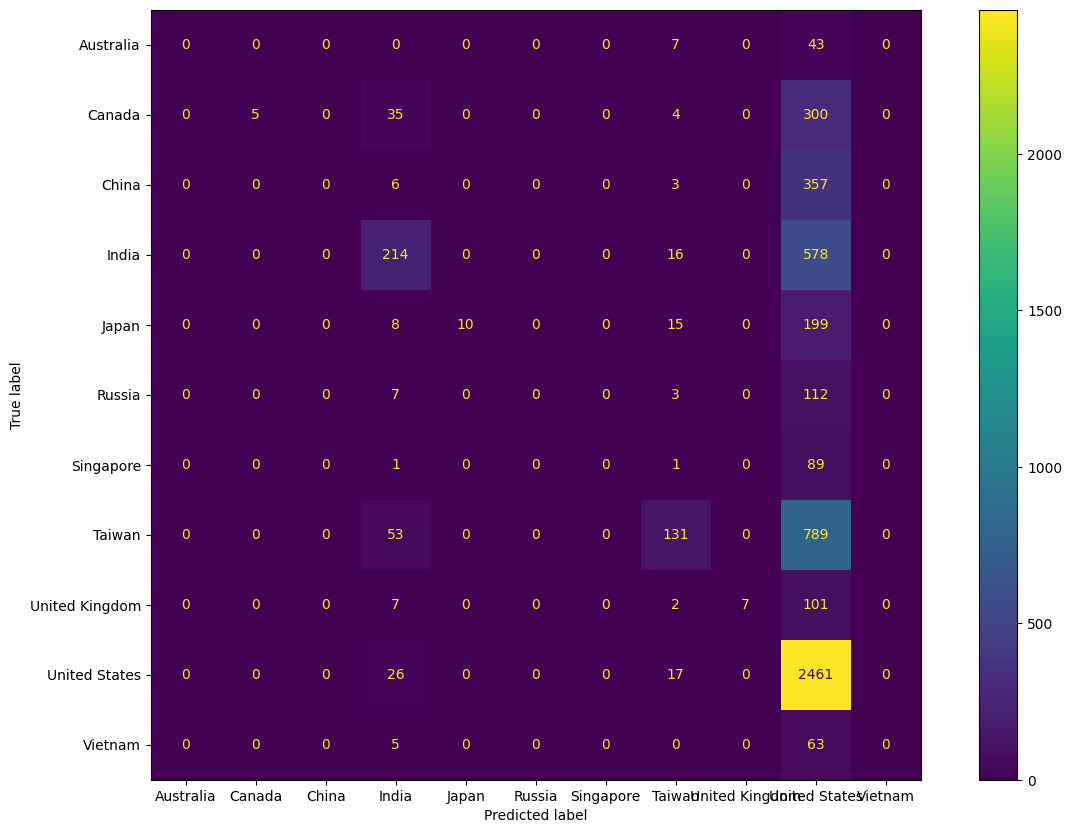

In [ ]:
y_pred_train = svc_cv.predict(X_train_combined)

print(classification_report(y_train, y_pred_train))

print("f1_score : ",f1_score(y_train, y_pred_train, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_train, y_pred_train), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

     Australia       0.00      0.00      0.00        85
        Canada       0.00      0.00      0.00        91
         China       0.00      0.00      0.00        58
         India       0.32      0.17      0.22       220
         Japan       0.00      0.00      0.00        11
        Russia       0.00      0.00      0.00         3
     Singapore       0.00      0.00      0.00        57
        Taiwan       0.13      0.04      0.06       142
United Kingdom       0.00      0.00      0.00         7
 United States       0.54      0.94      0.69       810
       Vietnam       0.00      0.00      0.00        75

      accuracy                           0.51      1559
     macro avg       0.09      0.10      0.09      1559
  weighted avg       0.34      0.51      0.39      1559

f1_score :  0.3941242337508798


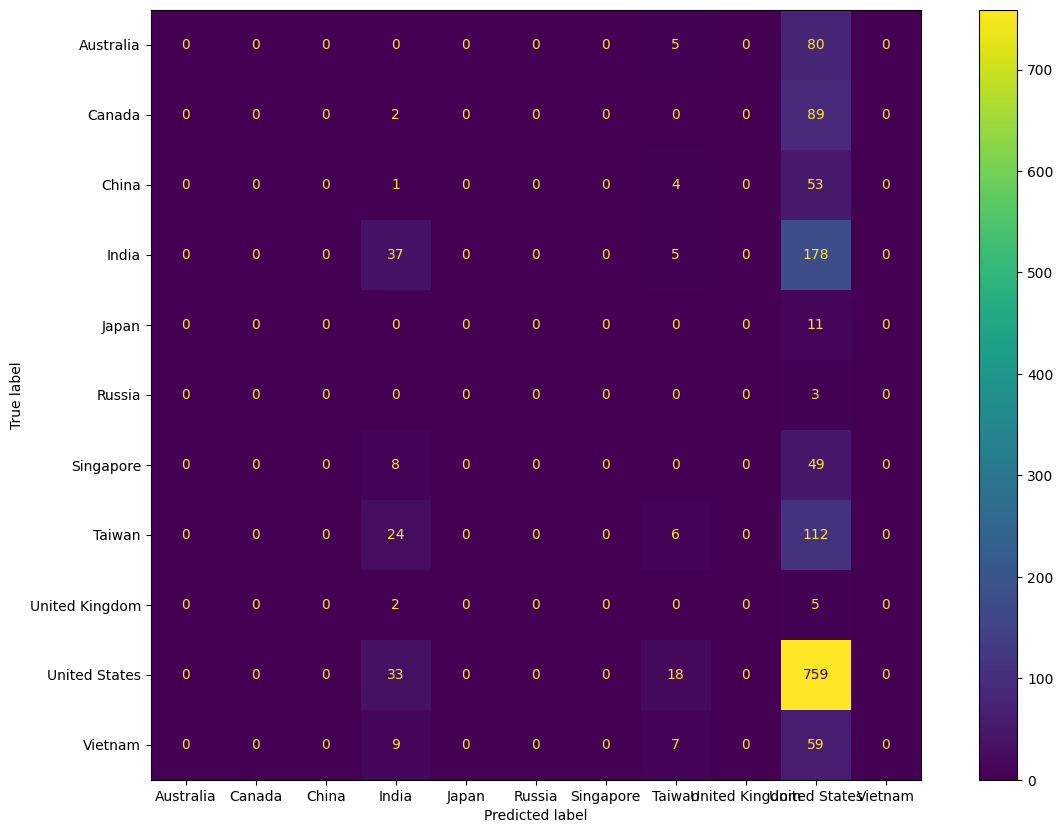

In [ ]:
y_pred_test = svc_cv.predict(X_test_combined)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()